In [127]:
import sys
sys.path.append('../')
from utils_models import *


In [2]:
amp_with_2pi = 9.13069185e-03
Ej_transmon = 3.40890048e+01
pulse_length = 2.47029937e+02 - 3.029937000000018 # a manual correction

t_rise = 30
t_tot = t_rise + pulse_length
tlist = np.linspace(0,t_tot,int(t_tot))

fluxonium = scqubits.Fluxonium(EJ=2.7,
                        EC=0.6,
                        EL=0.13,
                        flux=0,cutoff=110,
                        truncated_dim=20)
transmon = scqubits.Transmon(
    EJ=Ej_transmon,
    EC=0.2,
    ng=0.0,
    ncut=10,
    truncated_dim = 4
    )
system = FluxoniumTransmonSystem(
    fluxonium  = fluxonium,
    transmon = transmon,
    computaional_states = '1,2',
    g_strength = 0.2,
    )


w_d = system.evals[system.product_to_dressed[(0,1)]] - system.evals[system.product_to_dressed[(0,0)]]


In [4]:
system.filtered_product_to_dressed

{(0, 0): 1,
 (0, 1): 12,
 (0, 2): 31,
 (0, 3): 49,
 (1, 0): 2,
 (1, 1): 13,
 (1, 2): 32,
 (1, 3): 50}

In [5]:
system.sign_multiplier

{1: -1, 12: -1, 31: -1, 49: -1, 2: -1, 13: -1, 32: -1, 50: 1}

In [8]:
print(f"tmon lvl0 qbt freq: {system.evals[system.product_to_dressed[(2,0)]] - system.evals[system.product_to_dressed[(1,0)]]}")
print(f"tmon lvl1 qbt freq: {system.evals[system.product_to_dressed[(2,1)]] - system.evals[system.product_to_dressed[(1,1)]]}")
print(f"diff: {(system.evals[system.product_to_dressed[(2,0)]] - system.evals[system.product_to_dressed[(1,0)]]) - (system.evals[system.product_to_dressed[(2,1)]] - system.evals[system.product_to_dressed[(1,1)]])}")

tmon lvl0 qbt freq: 0.01896425212577668
tmon lvl1 qbt freq: 0.01894335383882151
diff: 2.0898286955173262e-05


In [3]:
e_ops = []
for ql in range(8):
    for tl in range(4):
        e_ops.append(system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(ql,tl)]))))

results = system.run_qutip_mesolve_parrallel(
        initial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, i)) for i in range(3)],
        tlist = tlist,
        drive_terms = [DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.transmon.n_operator)),
                pulse_shape_func=square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d': w_d,
                    'amp': amp_with_2pi/(2*np.pi),
                    't_rise': t_rise,
                    't_square': pulse_length - t_rise
                  },
                )],
        c_ops = None,
        e_ops = e_ops
    )


 /home/kai/miniconda3/envs/test/lib/python3.10/site-packages/loky/backend/fork_exec.py: 382024-03-28 17:05:44.996861: E external/xla/xla/stream_executor/cuda/cuda_driver.cc:280] failed call to cuInit: UNKNOWN ERROR (801)
CUDA backend failed to initialize: FAILED_PRECONDITION: No visible GPU devices. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)
2024-03-28 17:05:45.004230: E external/xla/xla/stream_executor/cuda/cuda_driver.cc:280] failed call to cuInit: UNKNOWN ERROR (801)
CUDA backend failed to initialize: FAILED_PRECONDITION: No visible GPU devices. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)
2024-03-28 17:05:45.011937: E external/xla/xla/stream_executor/cuda/cuda_driver.cc:280] failed call to cuInit: UNKNOWN ERROR (801)
CUDA backend failed to initialize: FAILED_PRECONDITION: No visible GPU devices. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


 Total run time:  87.92s*] Elapsed 87.92s / Remaining 00:00:00:00
 [*********99%***********] Elapsed 87.93s / Remaining 00:00:00:00

Processing states with pad_back_custom: 100%|██████████| 277/277 [00:00<00:00, 7566.41it/s]


 Total run time:  88.57s*] Elapsed 88.57s / Remaining 00:00:00:00


Processing states with pad_back_custom: 100%|██████████| 277/277 [00:00<00:00, 7520.32it/s]


 Total run time:  89.88s*] Elapsed 89.88s / Remaining 00:00:00:00


Processing states with pad_back_custom: 100%|██████████| 277/277 [00:00<00:00, 7380.63it/s]


(-1e-05, 0.0001)

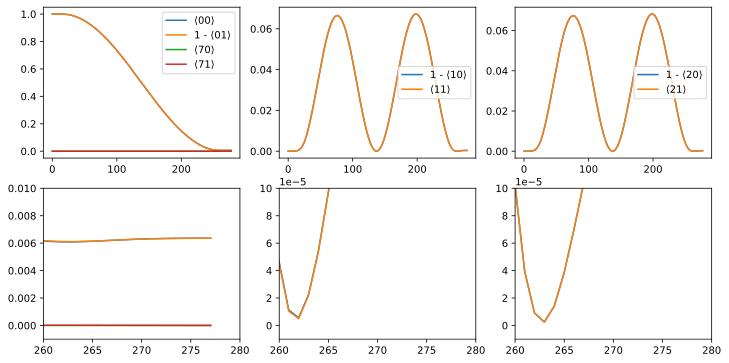

In [4]:
colors = ['green','red','darkorange']
fig,axes = plt.subplots(2,3,figsize = (12,6))
for col, levels_list in zip([0,1,2],
                    [
                        [(0,0),(0,1),(7,0),(7,1)],
                        [(1,0),(1,1)],
                        [(2,0),(2,1)]
                    ]):
    for row in [0,1]:
        for (ql,tl) in levels_list:
            i = ql*4+tl
            if (ql,tl) not in [(0,1), (1,0),(2,0)]:
                axes[row, col].plot(tlist,results[col].expect[i],label = rf"$\langle{ql}{tl}\rangle$")
            else:
                axes[row, col].plot(tlist,1 - results[col].expect[i],label = rf"1 - $\langle{ql}{tl}\rangle$")
    axes[0,col].legend()
    # axes[1,col].axvline(x=270, color='b', linestyle='--')
    axes[1,col].set_xlim(260,280)

axes[1,0].set_ylim(-1e-3,1e-2)
axes[1,1].set_ylim(-1e-5,1e-4)
axes[1,2].set_ylim(-1e-5,1e-4)


In [ ]:
evals, evecs = system.hilbertspace.hamiltonian().eigenstates()
overlap_matrix = scqubits.utils.spectrum_utils.convert_evecs_to_ndarray(evecs)


print(f"\t\tqubit 0\t\t\tqubit 1 \t\t qubit 2")

print(f"osc lvl\t\tdressed-overlap^2\tdressed-overlap^2\tdressed-overlap^2")
for i in range(2):
    product_index_q0 = 0 * system.transmon.truncated_dim + i
    product_index_q1 = 1 * system.transmon.truncated_dim + i
    product_index_q2 = 2 * system.transmon.truncated_dim + i

    overlaps_with_product_state_q0 = np.abs(overlap_matrix[:, product_index_q0])
    sorted_indices_q0 = np.argsort(overlaps_with_product_state_q0)[::-1]
    sorted_overlaps_q0 = overlaps_with_product_state_q0[sorted_indices_q0]

    overlaps_with_product_state_q1 = np.abs(overlap_matrix[:, product_index_q1])
    sorted_indices_q1 = np.argsort(overlaps_with_product_state_q1)[::-1]
    sorted_overlaps_q1 = overlaps_with_product_state_q1[sorted_indices_q1]
    
    overlaps_with_product_state_q2 = np.abs(overlap_matrix[:, product_index_q2])
    sorted_indices_q2 = np.argsort(overlaps_with_product_state_q2)[::-1]
    sorted_overlaps_q2 = overlaps_with_product_state_q2[sorted_indices_q2]

    print(f"tl-{i}:\t\t{list(sorted_indices_q0)[0]}-{list(sorted_overlaps_q0)[0]**2:.3f} \t\t{list(sorted_indices_q1)[0]}-{list(sorted_overlaps_q1)[0]**2:.3f} \t\t{list(sorted_indices_q2)[0]}-{list(sorted_overlaps_q2)[0]**2:.3f}")

		qubit 0			qubit 1 		 qubit 2
osc lvl		dressed-overlap^2	dressed-overlap^2	dressed-overlap^2
tl-0:		0-1.000 		1-1.000 		2-1.000
tl-1:		7-0.863 		12-0.988 		13-0.996


In [6]:
state_0_dressed = qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(1,0)])
state_1_dressed = qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(2,0)])
state_plus_dressed = (state_0_dressed  +  state_1_dressed).unit()
state_minus_dressed = (state_0_dressed  -  state_1_dressed).unit()
state_plus_i_dressed = (state_0_dressed + 1j * state_1_dressed).unit()
state_minus_i_dressed = (state_0_dressed - 1j * state_1_dressed).unit()
initial_states  = [
    state_0_dressed,
    state_1_dressed,
    state_plus_dressed,
    state_minus_dressed,
    state_plus_i_dressed,
    state_minus_i_dressed,
    ]

results = system.run_qutip_mesolve_parrallel(
        initial_states =initial_states,
        tlist = tlist,
        drive_terms = [DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.transmon.n_operator)),
                pulse_shape_func=square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d': w_d,
                    'amp': amp_with_2pi/(2*np.pi),
                    't_rise': t_rise,
                    't_square': pulse_length - t_rise
                  },
                )],
        c_ops = None,
        e_ops = None,
        post_processing = ['pad_back','partial_trace_computational_states']
    )


 /home/kai/miniconda3/envs/test/lib/python3.10/site-packages/loky/backend/fork_exec.py: 38

2024-03-28 17:30:26.257183: E external/xla/xla/stream_executor/cuda/cuda_driver.cc:280] failed call to cuInit: UNKNOWN ERROR (801)
CUDA backend failed to initialize: FAILED_PRECONDITION: No visible GPU devices. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)
2024-03-28 17:30:26.269801: E external/xla/xla/stream_executor/cuda/cuda_driver.cc:280] failed call to cuInit: UNKNOWN ERROR (801)
CUDA backend failed to initialize: FAILED_PRECONDITION: No visible GPU devices. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)
2024-03-28 17:30:26.274916: E external/xla/xla/stream_executor/cuda/cuda_driver.cc:280] failed call to cuInit: UNKNOWN ERROR (801)
2024-03-28 17:30:26.275293: E external/xla/xla/stream_executor/cuda/cuda_driver.cc:280] failed call to cuInit: UNKNOWN ERROR (801)
CUDA backend failed to initialize: FAILED_PRECONDITION: No visible GPU devices. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)
CUDA backend failed to initialize: FAILED_PRECONDITION: No visible GPU dev

 Total run time: 177.89s*] Elapsed 177.89s / Remaining 00:00:00:00 [*********89%********   ] Elapsed 161.82s / Remaining 00:00:00:19
 [*********99%***********] Elapsed 178.10s / Remaining 00:00:00:01

Processing states with dressed_to_2_level_dm:  43%|████▎     | 117/274 [00:00<00:00, 1151.92it/s]

 [*********99%***********] Elapsed 178.22s / Remaining 00:00:00:01

...

Processing states with dressed_to_2_level_dm: 100%|██████████| 274/274 [00:00<00:00, 1201.41it/s]


 Total run time: 180.30s*] Elapsed 180.30s / Remaining 00:00:00:00
 Total run time: 180.37s*] Elapsed 180.37s / Remaining 00:00:00:00
 [*********99%***********] Elapsed 180.43s / Remaining 00:00:00:01

Processing states with dressed_to_2_level_dm: 100%|██████████| 274/274 [00:00<00:00, 1221.87it/s]


 Total run time: 181.61s*] Elapsed 181.61s / Remaining 00:00:00:00


Processing states with dressed_to_2_level_dm: 100%|██████████| 274/274 [00:00<00:00, 1110.61it/s]


100%|██████████| 274/274 [00:11<00:00, 24.51it/s]


Text(0.5, 0, 't (ns)')

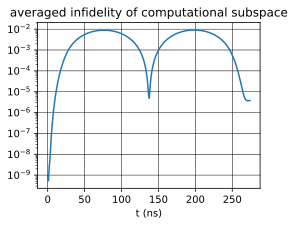

In [7]:
num_time_steps = len(results[0].times)
tlist = results[0].times


zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [
                zero,
                one,
                (zero +  one).unit(),
                (zero -  one).unit(),
                (zero + 1j * one).unit(),
                (zero - 1j * one).unit(),
                ]


def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(new_dm, dm_ideal))
        # fid.append(qutip.fidelity(dm, gate*dm_ideal))
    return 1-sum(fid)/len(fid)


from scipy.optimize import minimize

infidelity1 = []
phase_lump = []
for idx in tqdm(range(num_time_steps)):
    dms = [result.states_dressed_to_2_level_dm[idx] for result in results]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity1.append(opt_result.fun)
    phase_lump.append(opt_result.x[0])


plt.figure(figsize = (4,3))

plt.plot(tlist,infidelity1,label = rf'$\kappa = 10^{-3}$')

plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
# plt.minorticks_on()
# plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

# plt.legend()

plt.yscale('log')
plt.title(rf"""averaged infidelity of computational subspace""")
plt.xlabel("t (ns)")

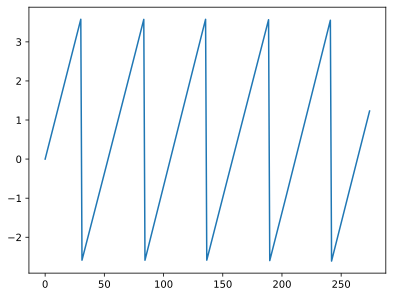

In [12]:
plt.plot(tlist,phase_lump,label = rf'$\kappa = 10^{-3}$')


In [80]:
product_to_dressed = system.product_to_dressed
qbt_position = system.qbt_position
filtered_product_to_dressed = system.filtered_product_to_dressed
sign_multiplier = system.sign_multiplier

def convert_to_product_with_first_subsystem_truncated(dressed_dm_data):
    if dressed_dm_data.shape[1] == 1:
        dressed_dm_data = qutip.ket2dm(dressed_dm_data)
    dressed_dm_data = dressed_dm_data.full()

    # Infer subsystem dimensions
    subsystem_dims = [max(indexes) + 1 for indexes in zip(*product_to_dressed.keys())]
    subsystem_dims[qbt_position] = 2
    rho_product = np.zeros((subsystem_dims*2), dtype=complex) # Here rho_product is shaped like (dim1,dim2,dim1,dim2)
    for product_state, dressed_index1 in filtered_product_to_dressed.items():
        for product_state2, dressed_index2 in filtered_product_to_dressed.items():
            element = dressed_dm_data[dressed_index1, dressed_index2] * sign_multiplier[dressed_index1] * sign_multiplier[dressed_index2]
            rho_product[product_state+product_state2] += element # Using index like (lvl1, lvl2, lvl1, lvl2) to access of of the entries
    two_lvl_qbt_dm_size = np.prod(subsystem_dims)
    rho_product = rho_product.reshape((two_lvl_qbt_dm_size,two_lvl_qbt_dm_size))
    rho_product = qutip.Qobj(rho_product, dims=[subsystem_dims, subsystem_dims])
    return rho_product

def calc_infidelity_with_phase_for_single_osc_lvl(theta,ol, rho, state_ideal):
    dim_1 = rho.dims[0][0]
    dim_2  =  rho.dims[0][1]
    gate = qutip.qip.operations.phasegate(theta[0])
    new_ideal = gate*state_ideal

    trunc_dm =qutip.Qobj(rho.full().reshape(rho.dims[0]+rho.dims[1])[:, ol, :, ol].reshape((dim_1, dim_1)), dims=[[dim_1], [dim_1]])
    fid = qutip.fidelity(trunc_dm, new_ideal)
    return 1 - fid
    

tot_time = results[0].times[-1]
tlist = np.linspace(0, tot_time, int(tot_time))
slice_interval = 20
new_tlist = tlist[::slice_interval]
num_time_steps = len(new_tlist)


phase1 = [[] for _ in range(4)]
for idx in tqdm(range(num_time_steps)):
    dms = [result.states_pad_back_custom[idx*slice_interval] for result in results]
    dms_two_lvl_qbt = [convert_to_product_with_first_subsystem_truncated(dm) for dm in dms]
    for ol in range(4):
        def objective_function(x):
            infidelities = [calc_infidelity_with_phase_for_single_osc_lvl(x,
                                                                ol,
                                                                dm_two_lvl,
                                                                state_ideal)  for dm_two_lvl, state_ideal in zip(dms_two_lvl_qbt,states_ideal)]
            mean = np.mean(infidelities)
            return mean
        x0 = [0.0]
        bounds = [(0, 2 * 3.141592653589793)]
        opt_result = minimize(objective_function, x0,method="COBYLA")
        phase1[ol].append(opt_result.x[0])


100%|██████████| 14/14 [00:03<00:00,  4.48it/s]


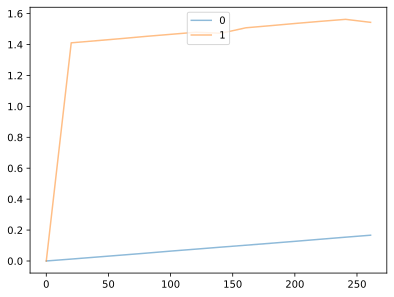

In [92]:
phase_list = np.array(phase1)

evals = system.fluxonium.eigenvals()
omega =  -1 *(evals[2]-evals[1])*2*np.pi
for i in range(2):
    resid = (np.array(phase_list[i]) - np.array(omega*new_tlist))%(2*np.pi)
    plt.plot(new_tlist,resid,label=f"{i}",alpha=0.5)
plt.legend(loc = 'upper center')

max overlap^2 0.09244678955409835 below threshold for dressed state 300 with eval 55.91083754946186
max overlap^2 0.014057301075872388 below threshold for dressed state 309 with eval 58.52741901372472
max overlap^2 0.0012048582130144315 below threshold for dressed state 314 with eval 60.29574295725968
max overlap^2 0.0012786888583510743 below threshold for dressed state 315 with eval 60.30324518438433
max overlap^2 0.0005080599390809157 below threshold for dressed state 345 with eval 69.80906742469686
max overlap^2 0.0006832625343938871 below threshold for dressed state 350 with eval 71.73761923232533
max overlap^2 0.0006851312956593828 below threshold for dressed state 351 with eval 71.73769035242839
max overlap^2 0.097544046098761 below threshold for dressed state 365 with eval 76.35109061909743
max overlap^2 0.0959564121977375 below threshold for dressed state 368 with eval 77.96023633728355
max overlap^2 0.09609091656412948 below threshold for dressed state 369 with eval 77.9603968

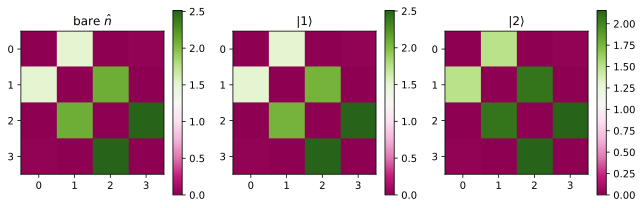

In [128]:
fluxonium = scqubits.Fluxonium(EJ=2.7,
                        EC=0.6,
                        EL=0.13,
                        flux=0,cutoff=110,
                        truncated_dim=20)
transmon = scqubits.Transmon(
    EJ=Ej_transmon,
    EC=0.2,
    ng=0.0,
    ncut=80,
    truncated_dim = 20
    )
system = FluxoniumTransmonSystem(
    fluxonium  = fluxonium,
    transmon = transmon,
    computaional_states = '1,2',
    g_strength = 0.2,
    )


operator_dressed = system.hilbertspace.op_in_dressed_eigenbasis(system.transmon.n_operator)

operator_bare = system.transmon.n_operator(energy_esys=True)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))  # 1 row, 3 columns


n_lvls =4

array1 = np.zeros((n_lvls, n_lvls))
for i in range(n_lvls):
    for j in range(n_lvls):
        array1[i, j] = np.abs(operator_bare[i, j])

array2 = np.zeros((n_lvls, n_lvls))
for i in range(n_lvls):
    for j in range(n_lvls):
        array2[i, j] = np.abs(operator_dressed[system.product_to_dressed[(1, i)], system.product_to_dressed[(1, j)]])

array3 = np.zeros((n_lvls, n_lvls))
for i in range(n_lvls):
    for j in range(n_lvls):
        array3[i, j] = np.abs(operator_dressed[system.product_to_dressed[(2, i)], system.product_to_dressed[(2, j)]])


arrays = [array1,array2,array3]
titles = [r'bare $\hat{{n}}$',r'$|1\rangle$', r'$|2\rangle$']
for i, ax in enumerate(axes):
    im = ax.imshow(arrays[i], cmap='PiYG', interpolation='nearest')
    ax.set_title(titles[i])
    fig.colorbar(im, ax=ax)  


plt.tight_layout()  # Adjust the layout to make room for the colorbar
plt.show()


In [126]:
def print_operator_elements(i,j):
    print(f"i={i},j={j}")
    bare_ele = operator_bare[i, j]
    one_ele = operator_dressed[system.product_to_dressed[(1, i)], system.product_to_dressed[(1, j)]]
    two_ele = operator_dressed[system.product_to_dressed[(2, i)], system.product_to_dressed[(2, j)]]
    print(f"{bare_ele}, abs: {abs(bare_ele)}")
    print(f"{one_ele}, abs: {abs(one_ele)}")
    print(f"{two_ele}, abs: {abs(two_ele)}")

print_operator_elements(0,1)
print_operator_elements(1,2)
print_operator_elements(2,3)


i=0,j=1
-1.4977724068397769, abs: 1.4977724068397769
(1.2236606094493847+0.8477844240602157j), abs: 1.4886516438701
(-1.4931179891414785-0.0786824530158404j), abs: 1.4951897063284252
i=1,j=2
-2.0861658626770874, abs: 2.0861658626770874
(-1.0566913859830327-1.7627250350681312j), abs: 2.0551876397221465
(-2.0747580396432492+0.1093329885251284j), abs: 2.077636788624069
i=2,j=3
-2.512938665754944, abs: 2.512938665754944
(-1.2888227701764032+2.149956167800427j), abs: 2.506666243517129
(2.067983218908636+0.6065472749810461j), abs: 2.155099577855895


In [136]:
evals, evecs = system.hilbertspace.hamiltonian().eigenstates()
overlap_matrix = scqubits.utils.spectrum_utils.convert_evecs_to_ndarray(evecs)

def print_overlap_lists(product_index):
    overlaps_with_product_state = np.abs(overlap_matrix[:, product_index])
    sorted_indices = np.argsort(overlaps_with_product_state)[::-1]
    sorted_overlaps = overlap_matrix[:, product_index][sorted_indices]
    for idx, overlap in zip(sorted_indices[:5], sorted_overlaps[:5]):
        print(f"{idx} , {overlap}")


for ql in [0,1]:
    for tl in [0,1]:
        print(f"\nql:{ql}, tl:{tl}")
        print_overlap_lists(ql * system.transmon.truncated_dim + tl)



ql:0, tl:0
0 , (0.999864417888835+0j)
15 , (-0.015622203367847884+0j)
12 , (0.0040214405969589105+0j)
20 , (-0.0022307843640939047+0j)
25 , (-0.0013817594968629783+0j)

ql:0, tl:1
7 , (-0.9288403781628375-0.008964677343423917j)
8 , (0.36726601313367696+0.0035488042223628755j)
3 , (-0.03803211863996367-2.4415158785903594e-05j)
35 , (0.0004946727518308774+0.022154865152519944j)
5 , (-0.014236666778335863+0.0001424192374062113j)

ql:1, tl:0
1 , (-0.5694181071783705-0.8218769869873294j)
22 , (-0.0020046714825259493+0.010811184127042715j)
18 , (-0.002926462383804698-0.009043785357630786j)
7 , (7.510479266118555e-05-0.00778169267505377j)
8 , (-1.665700548950666e-05+0.001723834738009003j)

ql:1, tl:1
12 , 0.9937679973474192j
11 , 0.10070921162981539j
6 , 0.034118827236333776j
4 , -0.01863505900426425j
42 , -0.014349533703572066j
